# Practical Machine Learning with SDSS Data

In this tutorial, we are going to use SDSS data to get some hands-on experience with machine learning. 

As a note in advance: none of the results you'll get out of this are science-worthy. This tutorial is meant to give you a first idea for how to set up your own machine learning model. But the first, and most important lesson, is this: **don't blindly trust your ML results.** 
As with any other science project, reporting or using results from a machine learning classifier or regressor requires careful understanding of the biases and caveats, assumptions and limitations that come with the data and algorithms chosen. Because the data sets you'll be using come straight out of the SDSS catalogue, you can expect there to be funny effects (both subtle and not) that may mess up any classification you'd want to do, and in a real-world setting, this would include understanding the limitations of the instrument and the data processing, before drawing any scientific conclusions from your procedure.

With that out of the way, let's have some fun with machine learning! In this tutorial, we will use python and a library called `scikit-learn` to do our machine learning, `pandas` to deal with data structures, and `matplotlib` and `seaborn` to do our plotting. 

In [1]:
# make plots interactive and import plotting functionality
import matplotlib.pyplot as plt

# pretty plotting
import seaborn as sns

# my standard styles for plots|
sns.set_style("whitegrid")
sns.set_context("talk")

# Always need numpy
import numpy as np

# data array operations
import pandas as pd

### A useful plotting function

This function will turn out useful later:

In [96]:
def plot_features(X, y, xl="dered_u", ylabels=["u_g_color", "g_r_color", "r_i_color", "i_z_color"]):
    """
    Plot a row of plots of features in X. 
    The label for the x-axis is given in `xl`, the labels for the y-axis in `ylabels`

    Parameters
    ----------
    X : pandas.DataFrame
        A DataFrame with the features

    y : iterable
        An iterable (list, array, DataFrame) with the class labels

    xl : str
        The column name of the feature to use on the x-axis

    ylabels : iterable of strings
        The column names of the features to use on the y-axis

    Returns
    -------
    fig, axes : the matplotlib Figure and Axes objects generated
    """
    fig, axes = plt.subplots(1, len(ylabels), figsize=(10,4))
    
    g_mask = (y == "GALAXY")
    
    for i,yl in enumerate(ylabels):
    
        axes[i].scatter(X.loc[g_mask, xl], 
                        X.loc[g_mask, yl], s=5, alpha=0.2,
                        label="galaxies")
    
        axes[i].scatter(X.loc[~g_mask, "dered_i"], 
                        X.loc[~g_mask, yl], s=5, alpha=1.,
                        label="stars")
        axes[i].set_ylim(np.percentile(X_train.loc[g_mask, yl], [0.1, 99.9]))
        axes[i].set_xlabel(xl)
        axes[i].set_ylabel(yl)
        if i == 0:
            axes[i].legend()
            
    plt.tight_layout()
    return fig, axes


def plot_misclassified(X, y, ypred):

    fig, axes = plt.subplots(1, 4, figsize=(10,4))

    g_mask = (y == "GALAXY")
    
    wrong_mask = (y != ypred) 
    
    xl = 0
    ylabels = [5, 6, 7, 8]
    
    for i,yl in enumerate(ylabels):
    
        axes[i].scatter(X[g_mask, xl], 
                        X[g_mask, yl], s=5, alpha=0.2,
                        label="galaxies")
    
        axes[i].scatter(X[~g_mask, 8], 
                        X[~g_mask, yl], s=5, alpha=0.5,
                        label="stars")
        
        axes[i].scatter(X[wrong_mask, 8], 
                        X[wrong_mask, yl], s=5, alpha=0.5,
                        label="stars")
    
    
        axes[i].set_ylim(np.percentile(X[g_mask, yl], [0.1, 99.9]))
        axes[i].set_xlabel(xl)
        axes[i].set_ylabel(yl)
        if i == 0:
            axes[i].legend()
            
    plt.tight_layout()

    return fig, axes

## The Scenario

You live in a universe where stars are rare, but galaxies are common. Maybe you are on a planet around a lone star far, far out in intergalactic space, in a big, lonely void. Anyway, you don’t know anything about stars, but you really need to, because you don’t really know what that big glowing ball you call a sun is doing. But you had a stroke of genius! You have the feeling that plotting the colour versus the magnitude will tell you all sorts of useful things, if only you could *find* the stars in your sample first! Luckily, you have a big telescope observing everything around you, and you have a catalogue full of measurements. Now all you have to do is find the stars, and find them well, or that plot you’re going to make won’t show you what you think it does … (also, you'll find out pretty quickly that you'll need distances to get this to work, but that's a story for another day ...)


### Load the Data

Our first task is loading the data. Your task is to load the data from the file `"sdss_dataset1.csv"` into a `pandas.DataFrame` (if you've never worked with pandas, take a look at the `read_csv` function):

In [3]:
# add your code for loading the data here:
data = pd.read_csv("sdss_dataset1_new.csv")

The `head` method on your loaded `DataFrame` gives you a quick overview of what's in your data:

In [4]:
data.head()

,objid,ra,dec,dered_u,dered_g,dered_r,dered_i,dered_z,mag_u,mag_g,mag_r,mag_i,mag_z,spec_z,u_g_color,g_r_color,r_i_color,i_z_color,class
0,1237648720142401611,146.71421,-1.041304,16.91713,15.31460,14.55245,14.14041,13.83297,18.85211,17.23538,16.46962,15.94119,15.61102,0.021222,1.602523,0.762152,0.412046,0.307439,GALAXY
1,1237650795146510627,146.74413,-0.652191,20.97757,18.85416,17.52073,17.00673,16.65681,21.98777,20.03968,18.74212,18.23019,17.88256,0.203783,2.123409,1.333426,0.514000,0.349922,GALAXY
2,1237650795146445031,146.62857,-0.765137,19.18432,17.34647,16.50649,16.07855,15.75247,20.57547,18.89972,17.98854,17.59275,17.24012,0.064656,1.837856,0.839977,0.427937,0.326082,GALAXY
3,1237648720142401670,146.63167,-0.988278,19.26245,18.15352,17.72428,17.43797,17.35491,20.72908,19.75962,19.46987,19.05719,18.96583,0.052654,1.108932,0.429235,0.286310,0.083057,GALAXY
4,1237648720142532891,146.91945,-0.990492,20.18201,18.45391,17.33205,16.89840,16.59294,22.42488,20.37280,19.02804,18.64363,18.23689,0.213861,1.728102,1.121861,0.433647,0.305468,GALAXY


Today, we're trying to distinguish stars from galaxies. This is a typical *supervised classification* problem. The first thing you'll have to do is set up your data for machine learning. 

**Question**: Which of the columns above would you use for classification? Which are your **labels**?

**Note**: Don't forget to remove the column with your classes/regression variable from the DataFrame, otherwise you'll use the thing you want to find as a feature, which makes your ML performance *really* good, but also *really* wrong! Take a look at the `drop` method for DataFrames to help you achieve that.

Some quick lingo: In machine learning, the things we are trying to learn are often called **labels**, and the quantities we can use to learn them are **features**. For example, in some of the data sets, you're going to try and separate stars and galaxies by their magnitudes and colours. Here, for each **sample** in your data set, you have a bunch of magnitude and colour measurements, your features, and you're trying to predict whether that sample is a galaxy or a star, its label. This is called **supervised learning**. 

Note that in this case, we always need examples where we *know* the ground truth: we need to know the class really well, or we need to know the redshift beyond a reasonable doubt (in our case here e.g. through precise spectroscopic measurements). This is often not the case in astronomy (or, indeed, science): we often don't know exactly what our labels should be. In these cases, **unsupervised learning** can be really helpful. Some of you have data sets without labels. You'll be playing around with clustering algorithms.

In [5]:
labels = data["class"]

In [6]:
features = data.drop("class", axis=1)

### Building a first classifier

Let's start by building a first, simple classifier/regressor. Normally, you wouldn't *start* by doing a classification, but for most of your data sets, there are some points we're going to make throughout this tutorial, so having a classification without knowing much about the data serves as a useful baseline. In general, though, running an ML algorithm comes at the end of *many* important steps, which is part of the point of this entire tutorial.

We're going to start working with the [k-nearest neighbour algorithm](https://en.wikipedia.org/wiki/K-nearest_neighbors_algorithm). This is one of the simplest machine learning algorithms out there. Essentially, it takes the $k$ nearest neighbours of a given sample and uses these neighbours to give an estimate of what the label for that sample should be. For the classification rpoblem, it assigns the majority vote of neighbour labels, for regression it assigns the average of the values of its $k$ nearest neighbours.

In `scikit-learn`, these live in `sklearn.neighbors` as [`KNeighborsClassifier`](http://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html#sklearn.neighbors.KNeighborsClassifier) and [`KNeighborsRegressor`](http://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsRegressor.html#sklearn.neighbors.KNeighborsRegressor). The unsupervised equivalent is in [`NearestNeighbors](http://scikit-learn.org/stable/modules/generated/sklearn.neighbors.NearestNeighbors.html#sklearn.neighbors.NearestNeighbors).

Try it out! Don't worry about the parameters right now, we'll do that further down below. 

**Hint**: Basically all algorithms implemented in scikit-learn have the same interface. Basically all of them have a `fit` method that will fit your data, a `predict` method that will predict the classes/values of new samples, and a `score` method that tells you something about how good your algorithm is at making predictions. Some algorithms also have a `transform` and a `fit_transform` method, which allows you to transform your features (e.g. dimensionality reduction algorithms like Principal Component Analysis). Many machine learning libraries outside of scikit-learn have adopted the same structure, which is super helpful when using these libraries for algorithms that are not implemented in scikit-learn. Learning how to do a workflow in scikit-learn is well worth the investment.

In [7]:
# import the correct class for your problem and instantiate it

from sklearn.neighbors import KNeighborsClassifier

kn = KNeighborsClassifier()

In [8]:
# fit the features and the labels we've just extracted
kn.fit(features, labels)

KNeighborsClassifier()

Let's *score* the model's performance. For most methods in scikit-learn, the `score` method calculates the *accuracy* of the predictions. That is, it uses the trained model to calculate predictions for all samples, and then counts all samples for which it predicted the right thing, and divides that by all samples. So the accuracy is the *fraction of samples where the algorithm predicted the correct number, divided by all examples*. 

In [9]:
# calculate the score for your data
kn.score(features, labels)

0.9746

What score did you get? It should hopefully be pretty high.

**Question**: Do you trust this score? Why? Why not? Are there ways you could make your score more trustworthy? 

## Training, Validation and Test Sets

Ok, so, are we done now? Obviously not, or this tutorial would be pretty short. :)
You hopefully just got a super high score on your classification/regression, but is this number actually useful? The answer is both yes and no. You just **trained** your data on a data set, but you also **tested** the model's performance on the *same* data. As a baseline, it's useful to know how well your algorithm does on the training data. In a simple example, imagine the quantity you're trying to predict lies on a parabola, but you're fitting a straight line to it. Even for your training data, the performance won't be great, because no matter what you do, your straight line won't do a good job of representing a parabola. 

But there is another problem here. Your performance on the same data you used to train your algorithm won't tell you anything about how well your algorithm generalizes to **new** examples, which is what we ultimately care about. It is easy, especially for some of the more complex algorithms, to make an arbitrarily complicated function that will reproduce the training data really well, but because it's so specifically trained on a specific data set, it'll do horribly on new examples. This is often called **overfitting**.

What we really need is some data we've never seen before, but for which we know what the output should be. In machine learning, it is standard to separate out a **test set**, i.e. part of the data for which you know the answer, but which you will not look at *until the very end*.

**Question**: So let's divide our data into a training and a test set. What fraction of your data do you think is appropriate to have in your training and your test set?


In [10]:
# split your existing array of features and labels into a training and a test set

ntraining = int(0.75*len(features))

f_train = features[:ntraining]
l_train = labels[:ntraining]

f_test = features[ntraining:]
l_test = labels[ntraining:]

**Important**: You  have to make sure that your training data and your test data are completely **independent from each other**! For example, if you work with overlapping segments in time, you'll have to make sure that there's no overlap between segments in your training data and your test data.

Now run your ML algorithm again, but use the *test data* in the score method (again, this is normally something you want to wait with until the *very end*, but there's going to be a point to this, I promise!):

In [11]:
# set up and train your algorithm as above, but only on the training data and labels
kn = KNeighborsClassifier()
kn.fit(f_train, l_train)

KNeighborsClassifier()

In [12]:
# now compute and print the accuracy score for both the training and the test data

print("The training score is: " + str(kn.score(f_train, l_train)))
print("The test score is: " + str(kn.score(f_test, l_test)))

The training score is: 1.0
The test score is: 0.8984


**Discuss**: Is this a good score? How well do the training and the test scores match? Are we done *now*? How could we figure out whether this is a good result or not?

No, of course we're not done. We haven't even really looked at our data yet! Some of you will have gotten a really great score, some of you won't. However, **a good accuracy score does not necessarily mean that you have a good, reliable model**. In machine learning applications, papers will often cite accuracy (or similar scores) as evidence that their model performs well. And this is true, but only for a limited number of circumstances. What's really important to know is how a model fails, and why it fails. A model with a high accuracy is still really *biased*, for example if it gets all redshifts in a certain part of parameter space wrong, or if it mis-classifies all stars as galaxies. Any conclusions we draw based on those classifications will be biased, too (for example, we might conclude there are no stars, because our algorithm didn't find some, and that would be really hard to explain in reality, seeing as the sun exists).  

**Exercise**: It's time to look at your data! Plot some of the columns in your data, and especially look at your predictions for the test set (you can get these using the `predict` method for your KNN classifier/regressor: where did the model do well? Where did it crash and burn? Are there any systematic trends in how it failed? Do you have any ideas for how you could fix your model or procedure?

In [13]:
# use these cells (feel free to make more, of course) to explore the data and your first classifier: where did it succeed? Where did it fail? 

In [14]:
y_test = kn.predict(f_test)

In [15]:
len(y_test)

5000

In [16]:
wrong_mask = np.array((y_test != l_test))

In [17]:
wrong_mask

array([False, False, False, ...,  True,  True,  True])

In [18]:
l_test[wrong_mask].value_counts()

class
STAR    508
Name: count, dtype: int64

In [19]:
l_test[~wrong_mask].value_counts()

class
GALAXY    4492
Name: count, dtype: int64

So my naive classifier has classified all of the galaxies correctly, but all of the stars incorrectly! If I were interested in stars especially, I'd be in trouble now!

In [20]:
from sklearn.metrics import f1_score

In [21]:
y_test

array(['GALAXY', 'GALAXY', 'GALAXY', ..., 'GALAXY', 'GALAXY', 'GALAXY'],
      dtype=object)

Here's an alternative

In [22]:
f1_score(np.array(l_test), np.array(y_test), average="macro")

0.47324062368310155

# Machine Learning: From Start To Finish

I set a really bad example above by (1) asking you to run the algorithm on the data before we'd even looked at it, and (2) using the test data set before we were ready. The idea was to give you an idea to explore some of the things that can go wrong with your machine learning if you're not careful. We're now going to do better, and run through a typical machine learning workflow from start to finish.


## Figuring out your goal: Asking why!

The first step in *any* research project, but certainly in any machine learning project, is to define your goal. What are you going to do with your results? Are you trying to learn something about physics with your data set? Are you just trying to separate out good signals from bad ones? 

Unfortunately, many physics questions don't necessarily easily translate to a machine learning problem (this is often true for statistics as well). Going from "I want to know what dark matter is" to "run a random forest on SDSS photometric measurements" is really hard, and requires multiple iterations of reducing your *physics* question down to one that ML or statistics (or a combination of the two) can answer. It's well worth spending significant time at this stage, because this process will give you crucial insights about every step of your analysis procedure, from which columns in your data might be useful, to which dimensionality reduction algorithms might work, to the type of appropriate ML algorithm to use. 

One important question I've already implicitly answered for you above: Do you have ground-truth labels in your training data? That is, do you have data for which you are reasonably sure that the labels assigned to each sample are correct? Another question I've already implicitly answered: Do you have a **classification** or a **regression** problem. In a classification problem, you have categorical labels (e.g. "star", "galaxy", ...) that you try to assign to new samples. In a regression context, the variable you try to assign is continuous (e.g. redshift). 

Here are some additional questions you might want to think about at the very start, but also keep in mind throughout your analysis:
* Do you only care about the *predictions*, or do I also care about the *parameters*? That is, are you trying to learn something about the structure of the problem itself (e.g. physics), or do you just care that the predictions are right?
* How well does your training data match the samples for which you don't know the labels? Are they from the same survey/instrument? Are there significant differences between the data you can train on, and the data you want to classify? 
* What biases do you already know if in your training data? Is your survey flux-limited? Did the team making the catalogue only care about a particular funny type of Cataclysmic Variable and leave out another you might be interested in? Is there a part of feature space that's just not covered? 
* What physical knowledge do you have about your measurements? How can that physics knowledge guide you in selecting or constructing good features? 



In this exercise, I am especially interested in finding stars! Stars are rare, and interesting, and therefore I want to find as many as I can, and then perhaps use those classification to learn something about where stars occur, and what they're made of. 

So this gives us a few constraints:
* We need to be able to reliably find *stars*, not just have a good overall classification accuracy
* We need to understand our biases: how well does our algorithm do in various parts of parameter space? 

This gives us some constraints on which algorithms we might want to use, and several other decisions we might want to make (e.g. with respect to scoring functions; see below).

## Feature Selection and Engineering

One of the crucial parts of machine learning, and the part that you will likely spend most of the time on, is selecting and engineering features for training on. Features are, essentially, meaningful summaries of your data that are ideally designed such that they make classification and regression easy. In terms of the problems you're considering today, notice that the magnitudes we've extracted from the SDSS catalogue are not actual data. They're measurements derived from the *images* that the telescope took. 

There are machine learning algorithms that can take raw data, e.g. the pixel values in an image. The most popular type used especially in image recognition in recent years is the Convolutional Neural Network (CNN), which takes raw data and essentially internally learns what good representations of the data are.

CNNs have been enormously successful for a whole number of tasks, but it's worth pointing out that they're not always the ideal solution. They're big and expensive to train (some of them can take weeks even on supercomputers!). If you have knowledge about the structure of your data and your problem, then it may be more efficient and reliable to use that knowledge to extract meaningful features. For example, we know that photons hit a CCD following a point spread function (PSF). We might not know that PSF very well, but if we do, there's no point making a neural network *learn* that a PSF exists; we can just extract magnitudes and work with them directly. So for any ML problem, it's worth thinking about what you know, and what you don't know. In cases where you *don't* know your PSF very well (or any number of things that may affect your measurements), it might be worth having your model learn that structure, but just take note that that's not universally true.

## Data Processing 1: Figuring out What's Happening in your Data

Let's now turn to the data you extracted. 

In any data set, you might have columns that are more useful than others! Let's find the ones we want to use for classification!

**Exercise**: Print the columns in your features table. What columns are there in your table? Are all of them useful for solving your problem? Are there combinations of columns (e.g. column1-column2) or modifications of columns (e.g. column3^2) that might be useful? Discuss with your team which ones might be useful, and which ones might not be! Reminder: you can look up what some of those columns mean [here](http://skyserver.sdss.org/dr14/en/help/browser/browser.aspx#&&history=description+SpecPhoto+V). 

In [23]:
# list all columns in the table
features.columns

Index(['objid', 'ra', 'dec', 'dered_u', 'dered_g', 'dered_r', 'dered_i',
       'dered_z', 'mag_u', 'mag_g', 'mag_r', 'mag_i', 'mag_z', 'spec_z',
       'u_g_color', 'g_r_color', 'r_i_color', 'i_z_color'],
      dtype='object')

In [24]:
features = features.drop(["objid", "ra", "dec", "spec_z"], axis=1)

In [25]:
features.columns

Index(['dered_u', 'dered_g', 'dered_r', 'dered_i', 'dered_z', 'mag_u', 'mag_g',
       'mag_r', 'mag_i', 'mag_z', 'u_g_color', 'g_r_color', 'r_i_color',
       'i_z_color'],
      dtype='object')


### Visualizing Feature Spaces

One of the most useful things you can do to star with is visualize your data! There are, of course, many different ways to visualize high-dimensional data. For example, you can make a histogram of the distributions for each feature (for classification problems, colour-coded by class works well), or you can make scatter plots or heatmaps of one feature against one another. You can also do both at the same time in what's called a *corner plot*. In python, the package `seaborn` has a lot of nice visualizations pre-built to cut down the time you need to deal with nitty-gritty details of making complicated plots work.

**Exercise**: Discuss and try out ways to visualize your features. Take a look at the [`pairplot`](https://seaborn.pydata.org/examples/scatterplot_matrix.html) function in seaborn. For the classification problems, look for features that separate stars and galaxies well. For the regression, try to gauge by looking at the features how complex a model you'll likely need. When you plot your features versus the redshift in `spec_z`, do the redshifts lie on straight line? Are there more complicated trends and structures in the data? 

/Users/danielahuppenkothen/work/sw/w/miniforge3/envs/teaching/lib/python3.11/site-packages/seaborn/axisgrid.py:2100: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


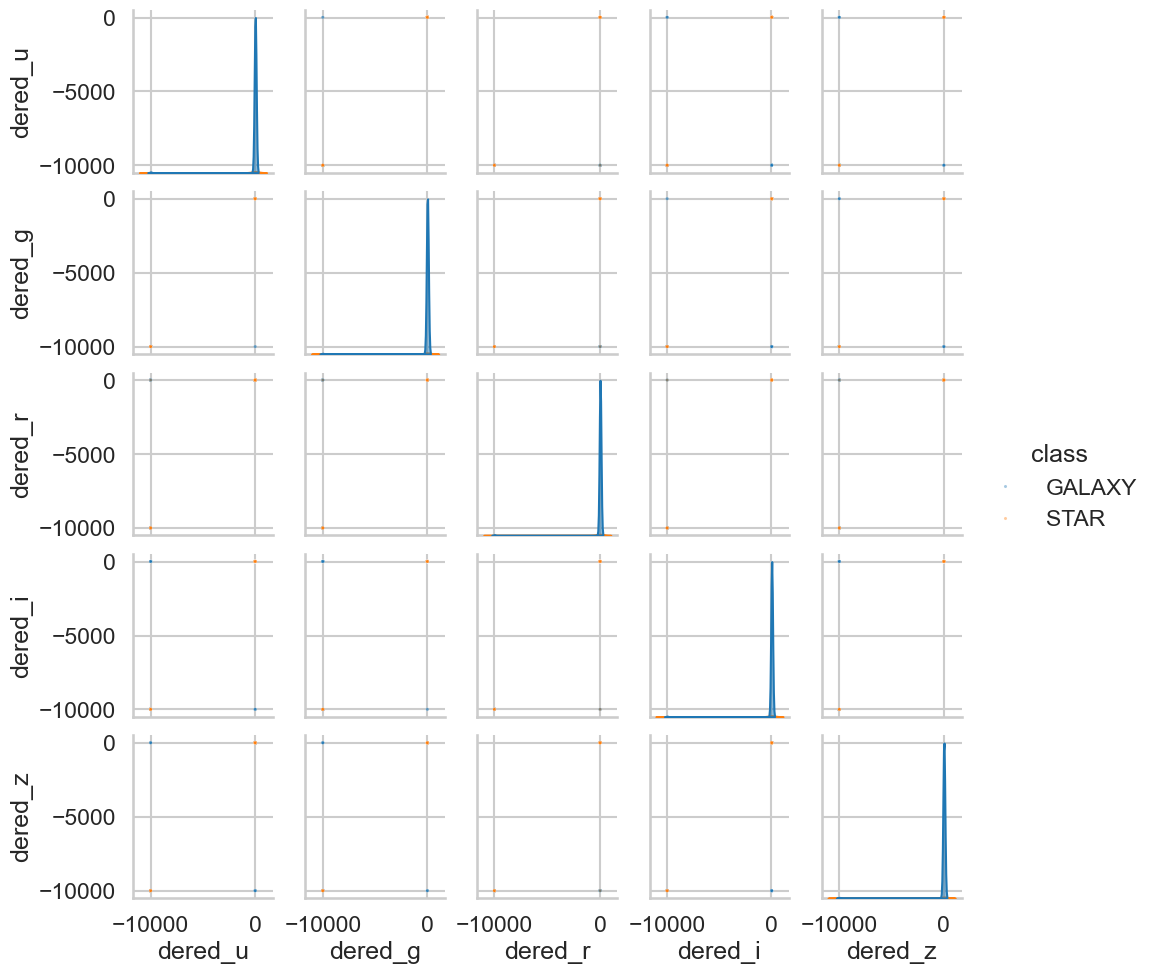

In [26]:
sns.pairplot(data.loc[:, ["dered_u", "dered_g", "dered_r", "dered_i", "dered_z", "class"]], 
             hue="class", size=2.0, plot_kws={"s":5, "alpha":0.4}, diag_kws={"alpha":0.5})

Ok, so what's going on here? Having magnitudes of -10000 is probably not very realistic, because, well, that would be *extremely* bright (for reference, the magnitude of the sun is ~-32). So this is probably a data issue. Let's see if we can deal with that:

In [27]:
mask = ((features["mag_u"] < -1000) | (features["mag_g"] < -1000) | (features["mag_r"] < -1000) | (features["mag_i"] < -1000) | (features["mag_z"] < -1000))

In [28]:
f_clean = features[~mask]

In [29]:
l_clean = labels[~mask]

In [30]:
len(f_clean)

19901

In [31]:
len(features)

20000

/Users/danielahuppenkothen/work/sw/w/miniforge3/envs/teaching/lib/python3.11/site-packages/seaborn/axisgrid.py:2100: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


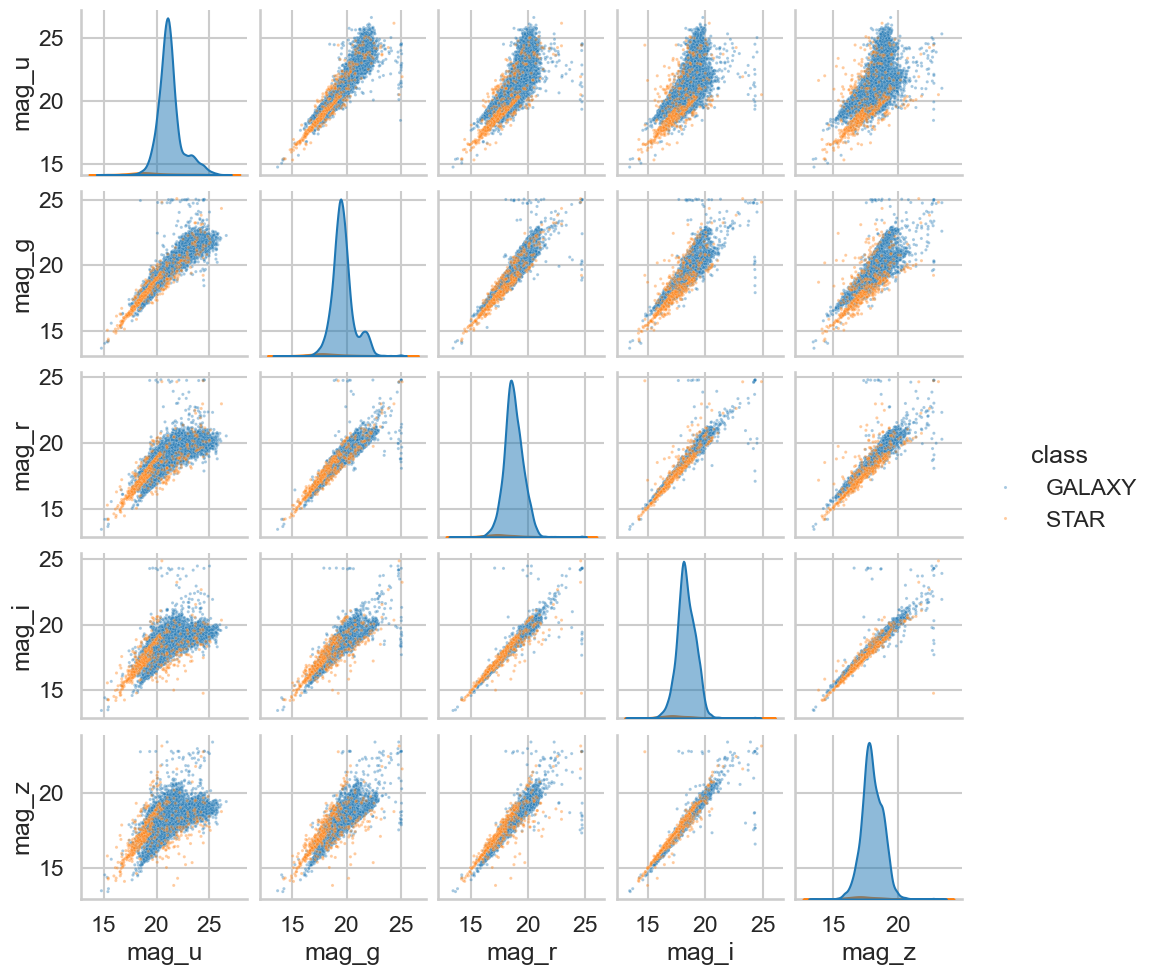

In [32]:
sns.pairplot(data.loc[~mask, ["mag_u", "mag_g", "mag_r", "mag_i", "mag_z", "class"]], 
             hue="class", size=2.0, plot_kws={"s":5, "alpha":0.4}, diag_kws={"alpha":0.5})

/Users/danielahuppenkothen/work/sw/w/miniforge3/envs/teaching/lib/python3.11/site-packages/seaborn/axisgrid.py:2100: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


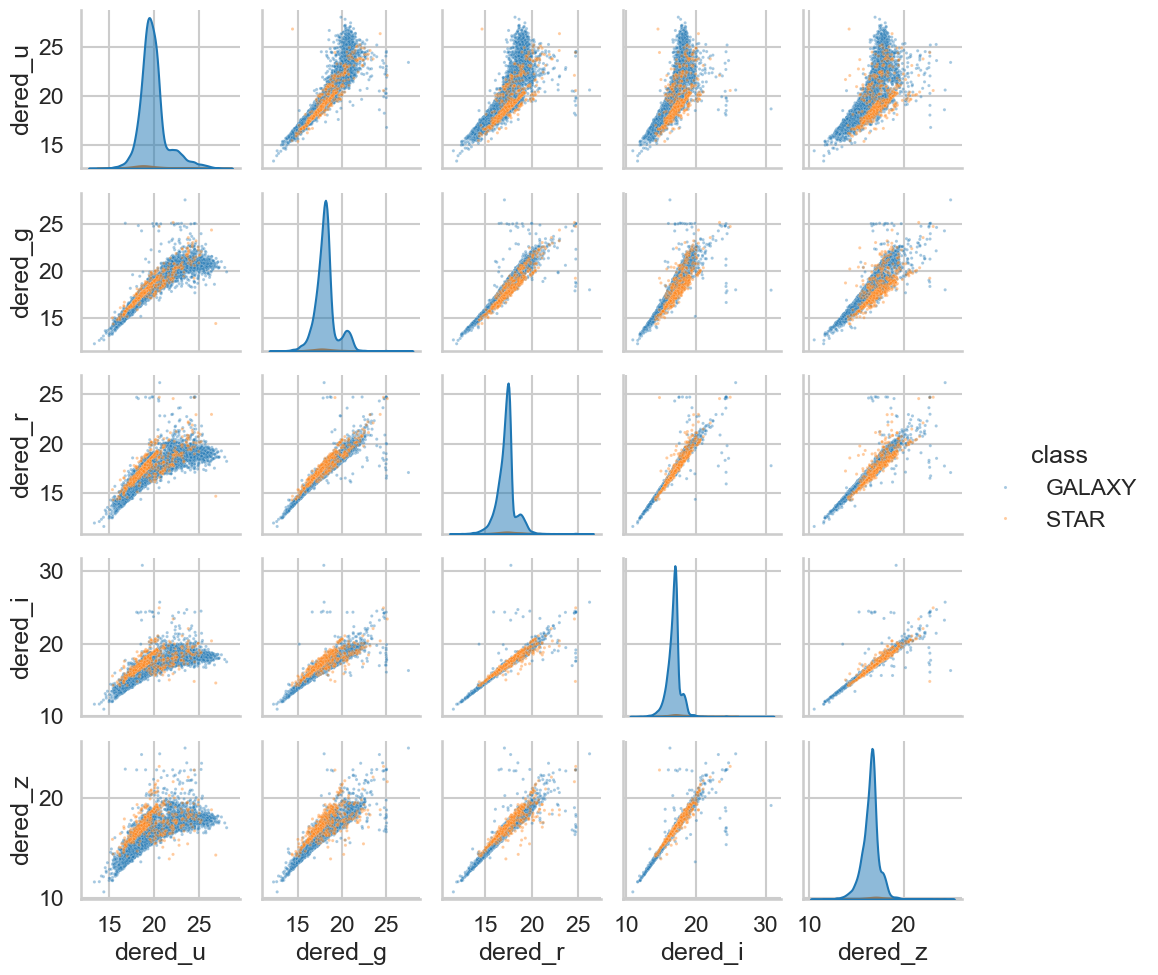

In [33]:
sns.pairplot(data.loc[~mask, ["dered_u", "dered_g", "dered_r", "dered_i", "dered_z", "class"]], 
             hue="class", size=2.0, plot_kws={"s":5, "alpha":0.4}, diag_kws={"alpha":0.5})

/Users/danielahuppenkothen/work/sw/w/miniforge3/envs/teaching/lib/python3.11/site-packages/seaborn/axisgrid.py:2100: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


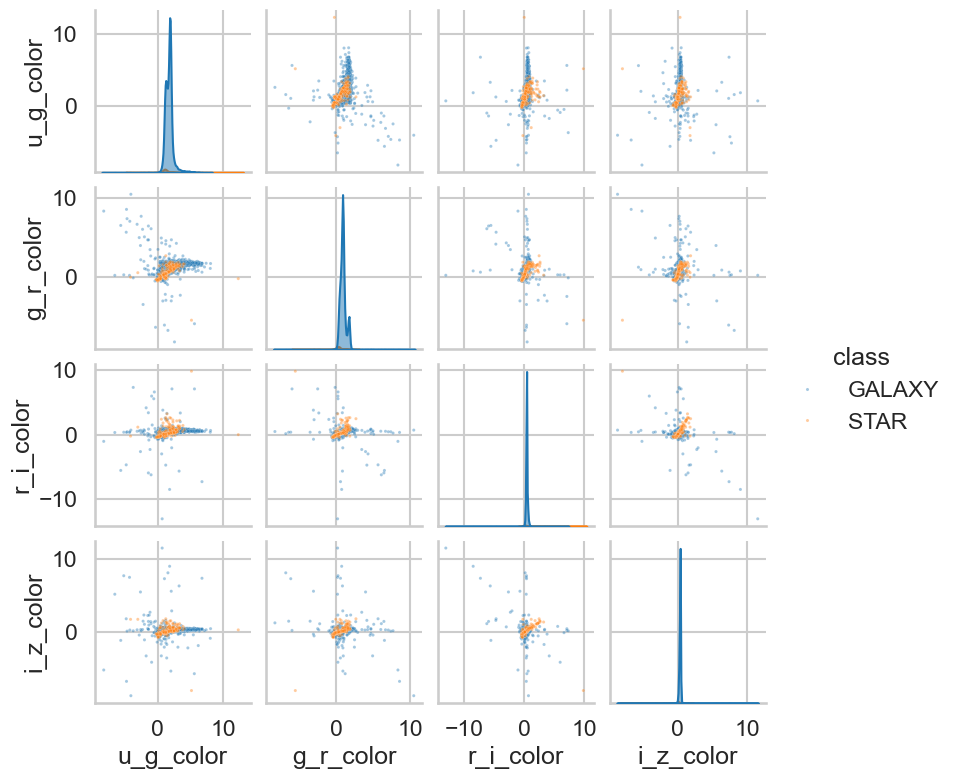

In [34]:
sns.pairplot(data.loc[~mask, ['u_g_color', 'g_r_color', 'r_i_color','i_z_color', "class"]], 
             hue="class", size=2.0, plot_kws={"s":5, "alpha":0.4}, diag_kws={"alpha":0.5})

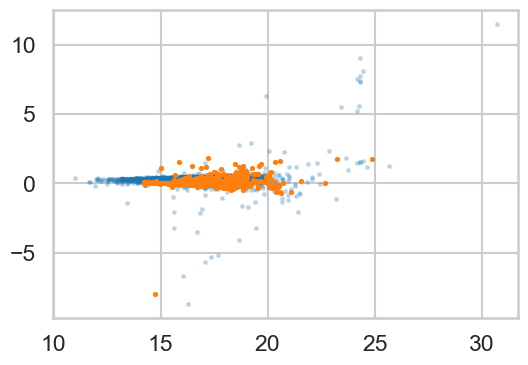

In [35]:
fig, ax = plt.subplots(1, 1, figsize=(6,4))

g_mask = (l_clean == "GALAXY")

xl = "dered_i"
yl = "i_z_color"
ax.scatter(f_clean.loc[g_mask, xl], 
           f_clean.loc[g_mask, yl], s=5, alpha=0.2)

ax.scatter(f_clean.loc[~g_mask, "mag_i"], 
           f_clean.loc[~g_mask, yl], s=5, alpha=1.)

Let's also remove the columns we don't want to use:

In [36]:
f_clean.head()

,dered_u,dered_g,dered_r,dered_i,dered_z,mag_u,mag_g,mag_r,mag_i,mag_z,u_g_color,g_r_color,r_i_color,i_z_color
0,16.91713,15.31460,14.55245,14.14041,13.83297,18.85211,17.23538,16.46962,15.94119,15.61102,1.602523,0.762152,0.412046,0.307439
1,20.97757,18.85416,17.52073,17.00673,16.65681,21.98777,20.03968,18.74212,18.23019,17.88256,2.123409,1.333426,0.514000,0.349922
2,19.18432,17.34647,16.50649,16.07855,15.75247,20.57547,18.89972,17.98854,17.59275,17.24012,1.837856,0.839977,0.427937,0.326082
3,19.26245,18.15352,17.72428,17.43797,17.35491,20.72908,19.75962,19.46987,19.05719,18.96583,1.108932,0.429235,0.286310,0.083057
4,20.18201,18.45391,17.33205,16.89840,16.59294,22.42488,20.37280,19.02804,18.64363,18.23689,1.728102,1.121861,0.433647,0.305468


In [37]:
f_clean = f_clean.drop( ["mag_u", "mag_g", "mag_r", "mag_i", "mag_z"], axis=1)

In [38]:
f_clean.head()

,dered_u,dered_g,dered_r,dered_i,dered_z,u_g_color,g_r_color,r_i_color,i_z_color
0,16.91713,15.31460,14.55245,14.14041,13.83297,1.602523,0.762152,0.412046,0.307439
1,20.97757,18.85416,17.52073,17.00673,16.65681,2.123409,1.333426,0.514000,0.349922
2,19.18432,17.34647,16.50649,16.07855,15.75247,1.837856,0.839977,0.427937,0.326082
3,19.26245,18.15352,17.72428,17.43797,17.35491,1.108932,0.429235,0.286310,0.083057
4,20.18201,18.45391,17.33205,16.89840,16.59294,1.728102,1.121861,0.433647,0.305468


## Train-Test Split, For Real

As I mentioned above, before we continue with our machine learning work, we'll want to separate out a test set, store it on disk and not think about it until we're entirely done with our analysis. The reason to do this is to make sure that this test set is entirely pristine and unseen: no information in it has in any way propagated into the analysis, except for the data issues we've been dealing with above. Let's do that now.

**Important**: Make sure that your training data is *randomized*, that is, it's not sorted by labels. Otherwise you might end up in the awkward situation that your training data only contains galaxies, and your test data only contains stars. `scikit-learn` has a handy function to help you with that:

In [39]:
from sklearn.model_selection import train_test_split

In [40]:
X_train, X_test, y_train, y_test = train_test_split(f_clean, l_clean, 
                                                    train_size=0.8, test_size=0.2,
                                                    shuffle=True, random_state=42)

In `scikit-learn` (and a lot of machine learning) `X` is conventionally the symbol for your training data or features, and `y` for the labels. the `shuffle=True` will randomize your data by rows as we want to. You can use `random_state` to fix the seed for the random number generator used in shuffling the data.

Because we have very few stars, let's make sure that we have some stars in both the training data and the test data, because it would be super easy for all your stars to end up in the training data by chance. 

You can do that using `pandas`'s `value_counts()` method:

In [41]:
y_train.value_counts()

class
GALAXY    15515
STAR        405
Name: count, dtype: int64

In [42]:
y_test.value_counts()

class
GALAXY    3886
STAR        95
Name: count, dtype: int64

Ok, there are a few in each. However, for very imbalanced data sets, you might want to make sure that this'll be the case. The `train_test_split` function has a keyword `stratify` that you can set to True and it'll make sure the fraction of stars in the training and test sets are similar to the overall fraction of stars in the data sets. We'll specify what we want to use for stratification, in our case it's just our labels:

In [43]:
X_train, X_test, y_train, y_test = train_test_split(f_clean, l_clean, 
                                                    train_size=0.8, test_size=0.2,
                                                    shuffle=True, stratify=l_clean, random_state=42)

In [44]:
y_train.value_counts()

class
GALAXY    15520
STAR        400
Name: count, dtype: int64

In [45]:
y_test.value_counts()

class
GALAXY    3881
STAR       100
Name: count, dtype: int64

In [46]:
len(y_test)

3981

Ok, so in our case, that's almost the same, but it's good that we've made sure. Now let's save the test data to file:

In [47]:
X_test.to_csv("sdss_dataset1_test.csv")
y_test.to_csv("sdss_dataset1_test_labels.csv")

In [48]:
X_test

,dered_u,dered_g,dered_r,dered_i,dered_z,u_g_color,g_r_color,r_i_color,i_z_color
451,20.14081,18.43025,17.70263,17.33621,17.14871,1.710566,0.727619,0.366421,0.187502
10347,19.31625,17.72975,17.01156,16.63057,16.37063,1.586496,0.718197,0.380985,0.259945
3153,21.07108,19.15829,17.67019,17.08202,16.64710,1.912796,1.488094,0.588171,0.434921
7687,19.48932,18.35139,18.00494,17.78185,17.67290,1.137924,0.346455,0.223091,0.108950
13020,20.79003,18.68674,17.40938,16.86964,16.56916,2.103292,1.277365,0.539738,0.300474
...,...,...,...,...,...,...,...,...,...
13936,26.55105,20.45103,18.46178,17.67704,17.27259,6.100019,1.989250,0.784740,0.404448
14691,21.95295,19.91335,18.36432,17.78055,17.40105,2.039597,1.549026,0.583775,0.379499
9223,19.39376,17.59227,16.72777,16.28404,15.96932,1.801489,0.864500,0.443733,0.314713
3718,19.21397,17.21449,16.18817,15.74375,15.36139,1.999485,1.026318,0.444414,0.382367


And from now on, we'll use the training data and ignore the test data to the very end of our analysis.

### Looking for Weird Things

One of the key tasks during this stage of your analysis is to *sanity-check* your data (specifically, your training data). Are there weird things? Instrumental artifacts? Things that don't look right? This is where you explore your data and try to find (and explain) these things, and potentially remove them before training.

**Exercise**: Take a close look at your features. Are there features in the data that look artificial? If so, can you think of ways to remove them?

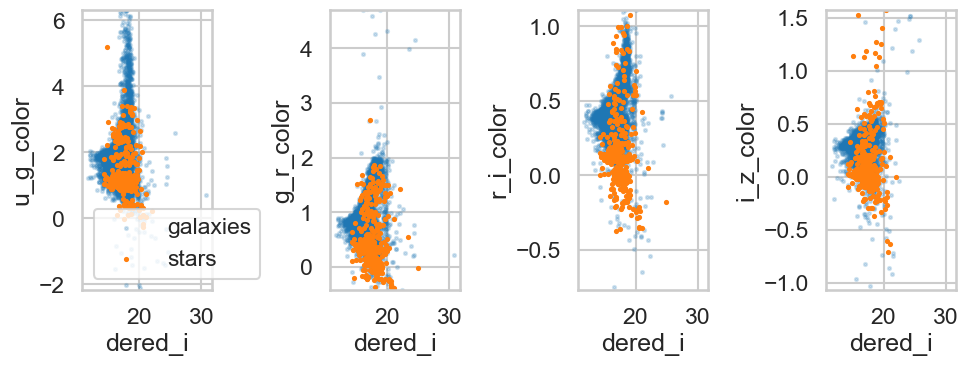

In [51]:
_, _ = plot_features(X_train, y_train, xl="dered_u")

This data looks pretty clean-ish on the first look.

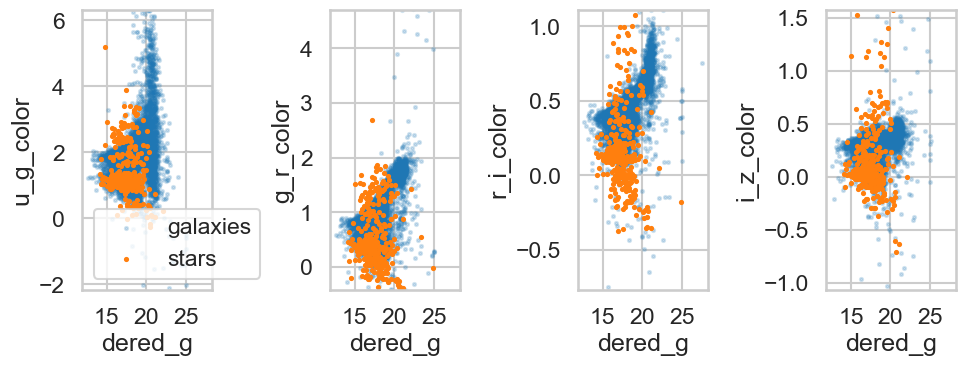

In [52]:
_, _ = plot_features(X_train, y_train, xl="dered_g")

(<Figure size 1000x400 with 4 Axes>,
 array([<Axes: xlabel='dered_r', ylabel='u_g_color'>,
        <Axes: xlabel='dered_r', ylabel='g_r_color'>,
        <Axes: xlabel='dered_r', ylabel='r_i_color'>,
        <Axes: xlabel='dered_r', ylabel='i_z_color'>], dtype=object))

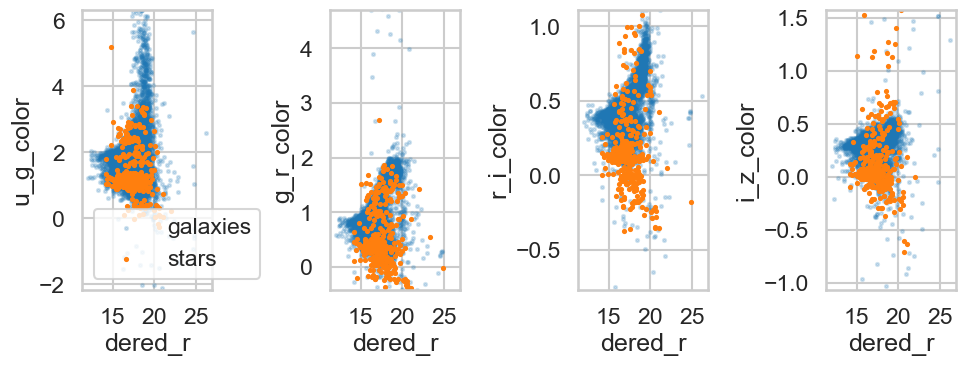

In [53]:
_, _ = plot_features(X_train, y_train, xl="dered_r")

(<Figure size 1000x400 with 4 Axes>,
 array([<Axes: xlabel='dered_i', ylabel='u_g_color'>,
        <Axes: xlabel='dered_i', ylabel='g_r_color'>,
        <Axes: xlabel='dered_i', ylabel='r_i_color'>,
        <Axes: xlabel='dered_i', ylabel='i_z_color'>], dtype=object))

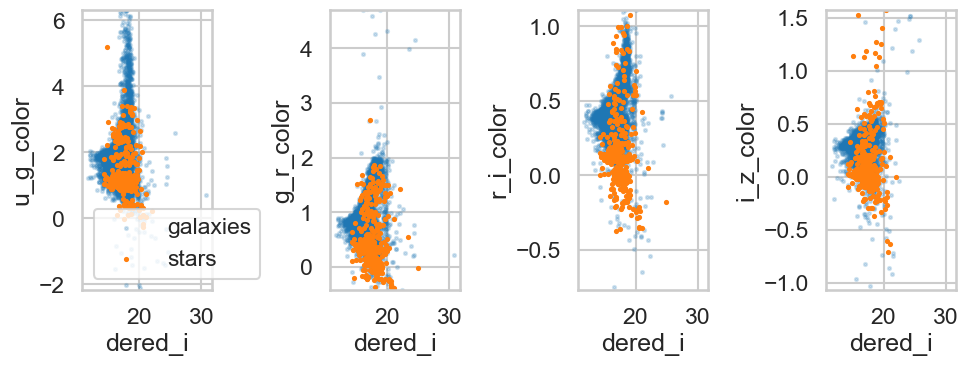

In [54]:
_, _ = plot_features(X_train, y_train, xl="dered_i")

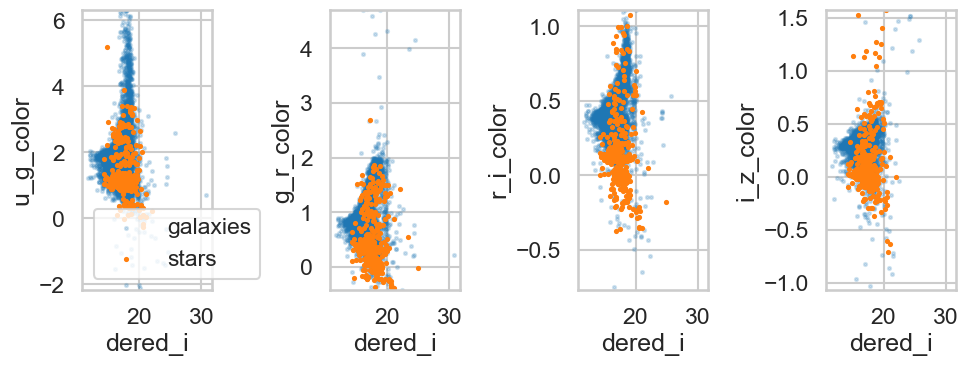

In [55]:
_, _ = plot_features(X_train, y_train, xl="dered_i")

### Dimensionality Reduction

Another way to try and make sense of high-dimensional feature spaces is to perform *dimensionality reduction*. There are a lot of different ways to reduce the dimensionality of your features, and some are more useful than others, depending on the structure of your data and your problem. One idea with dimensionality reduction is to find the combination of features that gives you the most useful information in terms of your regression or classification problem. Some other times, all you want is a handy visualization in 2D, since humans in general aren't very good at thinking in higher-dimensional spaces.

[Principal Component Analysis (PCA)](https://en.wikipedia.org/wiki/Principal_component_analysis) is one of the most straightforward ways of reducing dimensionality (see also [here](http://scikit-learn.org/stable/modules/classes.html#module-sklearn.decomposition) for alternative methods implemented in scikit-learn). One useful thing to try might be to project your features into a smaller space and see whether you still capture the information relevant in order to perform a good classification or regression.

**Exercise**: Use PCA to project your features into 2 dimensions, and compare with the full data space. Do you think most of the information in your features is captured by the 2D representation? 

**hint**: The `fit_transform` method will come in handy here.

In [56]:
from sklearn.decomposition import PCA

In [57]:
pca = PCA(n_components=2, whiten=False)

In [58]:
X_train.head()

,dered_u,dered_g,dered_r,dered_i,dered_z,u_g_color,g_r_color,r_i_color,i_z_color
13504,19.70813,17.94963,16.96432,16.51299,16.16032,1.758499,0.985306,0.451332,0.352673
15444,18.88892,17.79531,17.22843,16.83811,16.64927,1.093616,0.566874,0.390325,0.188841
7264,19.84497,18.19550,17.37945,16.97347,16.64811,1.649471,0.816053,0.405981,0.325361
6361,19.89322,18.17182,17.24706,16.85136,16.55344,1.721403,0.924765,0.395691,0.297928
17583,18.61216,17.11152,16.26201,15.83674,15.57832,1.500643,0.849514,0.425266,0.258422


In [59]:
f_pca = pca.fit_transform(X_train[["dered_u", "dered_g", "dered_r", "dered_i", "dered_z", 
                                   "u_g_color", "g_r_color", "r_i_color", "i_z_color", ]])

In [60]:
f_pca.shape

(15920, 2)

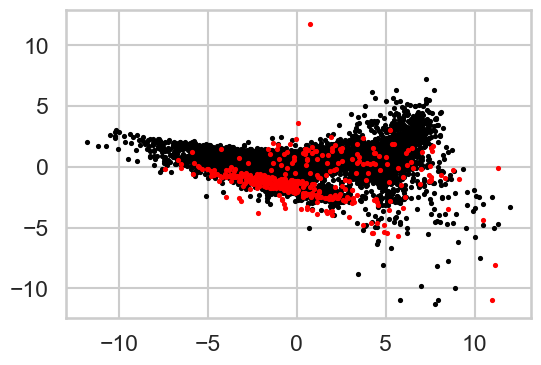

In [61]:
fig, ax = plt.subplots(1, 1, figsize=(6,4))

ax.scatter(f_pca[(y_train == "GALAXY"), 0], f_pca[(y_train == "GALAXY"), 1], s=5, color="black")
ax.scatter(f_pca[(y_train == "STAR"), 0], f_pca[(y_train == "STAR"), 1], s=5, color="red")

Another way to visualize high-dimensional data is called *t-distributed stochastic neighbour embedding*, or, for short, t-SNE. [The paper](https://lvdmaaten.github.io/publications/papers/JMLR_2008.pdf) is surprisingly readable for a computer science paper, and the method is generally pretty good at visualizing complex feature spaces (and you can spend some entertaining minutes letting your brain find fun things in the patterns it produces). 

**Beware**: One thing you have to be aware of, however, is that t-SNE *does not generalize to new examples*. Wheras methods like PCA can be trained on some data, and then the trained model applied to new samples, this is *not true* for t-SNE. So this is a method that's **useful for visualization**, but it **doesn't produce features you want to use in your classification**. Note that t-SNE is generally quite a slow algorithm, so running this on very large data sets might leave you waiting for a while!

**Exercise**: Let's try it out! Visualize your feature space in 2 dimensions using t-SNE (hint: this is also implemented in scikit-learn).

In [62]:
from sklearn.manifold import TSNE

In [63]:
ts = TSNE(n_components=2)

In [64]:
f_tsne = ts.fit_transform(X_train[["dered_u", "dered_g", "dered_r", "dered_i", "dered_z", 
                                   "u_g_color", "g_r_color", "r_i_color", "i_z_color", ]])

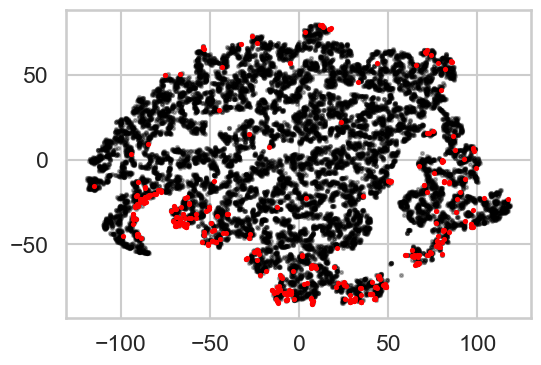

In [65]:
fig, ax = plt.subplots(1, 1, figsize=(6,4))

ax.scatter(f_tsne[(y_train == "GALAXY"), 0], f_tsne[(y_train == "GALAXY"), 1], s=5, color="black", alpha=0.3)
ax.scatter(f_tsne[(y_train == "STAR"), 0], f_tsne[(y_train == "STAR"), 1], s=5, color="red")

**Exercise (at home)**: For a different representation, take a look at the [UMAP package](https://umap-learn.readthedocs.io/en/latest/)

### Scaling Features

Sometimes, your features vary wildly in order of magnitude. You may have photometric magnitudes that all lie between 13 and 20, but maybe you have a feature that's between 1 and 1,000,000, so that your different dimensions have vastly different scales. Some algorithms (e.g. random forests) can deal with that pretty well, but others can't. It's worth knowing enough about the algorithms you use whether they will deal with this kind of issue or not. If the method can't, one common solution is to re-scale the features such that they all have a mean of zero and a variance of one. 

Scikit-learn has a few ways of scaling features and other potentially useful steps for pre-processing data. Take a look at [this tutorial](http://scikit-learn.org/stable/modules/preprocessing.html). Different scaling methods work differently well for different data sets (it depends on what you want to learn). The most common way of standard scaling is to take each feature (each column in your training data)

**Exercise**: Do you think scaling will help in your problem? Try scaling your features and re-running the PCA and t-SNE algorithms. Did your results change?

In [66]:
from sklearn.preprocessing import StandardScaler

In [67]:
scaler = StandardScaler()

In [68]:
X_scaled = scaler.fit_transform(X_train)

In [69]:
X_pca_sc = pca.fit_transform(X_scaled)

In [70]:
X_tsne_sc = ts.fit_transform(X_scaled)

Text(0.5, 1.0, 't-SNE on scaled features')

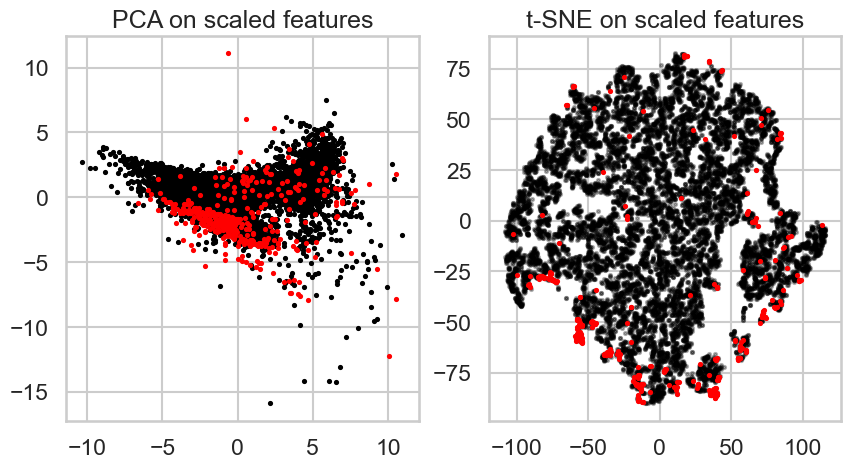

In [71]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,5))

ax1.scatter(X_pca_sc[(y_train == "GALAXY"), 0], X_pca_sc[(y_train == "GALAXY"), 1], s=5, color="black")
ax1.scatter(X_pca_sc[(y_train == "STAR"), 0], X_pca_sc[(y_train == "STAR"), 1], s=5, color="red")
ax1.set_title("PCA on scaled features")

ax2.scatter(X_tsne_sc[(y_train == "GALAXY"), 0], X_tsne_sc[(y_train == "GALAXY"), 1], s=5, color="black", alpha=0.3)
ax2.scatter(X_tsne_sc[(y_train == "STAR"), 0], X_tsne_sc[(y_train == "STAR"), 1], s=5, color="red")
ax2.set_title("t-SNE on scaled features")

In [72]:
X_train

,dered_u,dered_g,dered_r,dered_i,dered_z,u_g_color,g_r_color,r_i_color,i_z_color
13504,19.70813,17.94963,16.96432,16.51299,16.16032,1.758499,0.985306,0.451332,0.352673
15444,18.88892,17.79531,17.22843,16.83811,16.64927,1.093616,0.566874,0.390325,0.188841
7264,19.84497,18.19550,17.37945,16.97347,16.64811,1.649471,0.816053,0.405981,0.325361
6361,19.89322,18.17182,17.24706,16.85136,16.55344,1.721403,0.924765,0.395691,0.297928
17583,18.61216,17.11152,16.26201,15.83674,15.57832,1.500643,0.849514,0.425266,0.258422
...,...,...,...,...,...,...,...,...,...
12207,19.88042,18.07523,16.89135,16.43257,16.07528,1.805193,1.183880,0.458778,0.357290
14503,19.86734,17.90608,17.01882,16.60263,16.32196,1.961258,0.887260,0.416187,0.280672
9038,19.23183,18.03747,17.53982,17.17706,16.96213,1.194363,0.497648,0.362762,0.214926
12845,19.96649,18.24037,17.19941,16.74009,16.37268,1.726120,1.040964,0.459324,0.367401


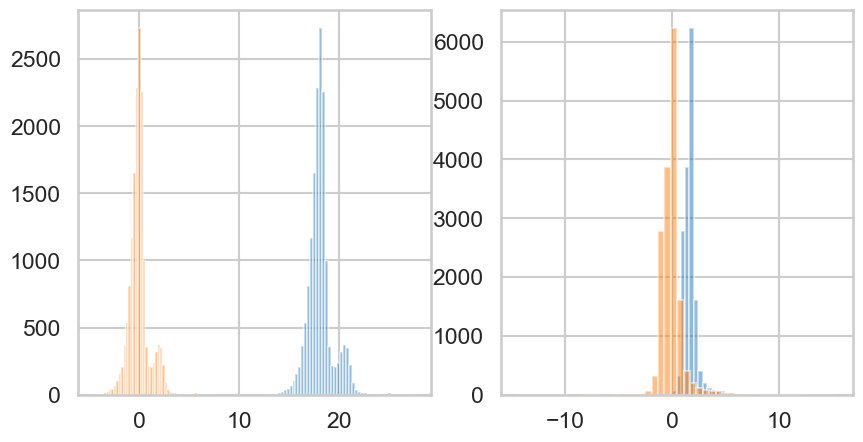

In [73]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

ax1.hist(X_train.loc[:,"dered_g"], alpha=0.5, bins=50)
ax1.hist(X_scaled[:,1], alpha=0.5, bins=50)

ax2.hist(X_train.loc[:,"u_g_color"], alpha=0.5, bins=50)
ax2.hist(X_scaled[:,5], alpha=0.5, bins=50);

## Train-Validation Splits

We've already split off a test data set, but that leaves us with a bit of an issue: how are we going to evaluate performance of our machine learning algorithm, if we can't touch the unseen data? 

The answer is to split off *another* test set, but to avoid confusion, we'll call this a validation set. The purpose of the validation set is to help us evaluate performace while we're designing the model, choosing hyperparameters and so on. Unlike the test set, we'll use this over and over during the analysis. 

Generally, we'd like to have the same number of validation samples as test samples. Above, we split out 20% of ~1000 samples (we removed some as not-real data), so ~2000 samples. Therefore, we'd also like to split ~2000 samples from our remaining data. They don't have to be *exactly* the same, but they should be close. Let's calculate what fraction that is of the remaining data:

In [74]:
val_frac = 4000/len(X_train)

In [75]:
X_train, X_val, y_train, y_val = train_test_split(np.array(X_scaled), np.array(y_train), train_size=0.75, 
                 shuffle=True, stratify=y_train, random_state=52)

In [76]:
len(X_train)

11940

In [77]:
len(X_val)

3980

## Picking a Machine Learning Algorithm to Start With

Which machine learning algorithm you choose for your problem depends, as we've discussed above, strongly on the type of problem you're trying to solve and the structure of the data. But even once you've decided whether you have a regression or classification problem, and whether it's an unsupervised or supervised one, there remain many algorithms to choose from!

All algorithms essentially do the same thing: they draw more or less complex functions in a multi-dimensional space (the number of dimensions corresponds to your number of features). Broadly, in the regression case, these methods try to find the best function to draw *through* the data points in order to model them. In the classification case, these methods try to find a surface that *separates* the different classes from another (this is also called a decision boundary). 

One big question is how *interpretable* the model ought to be. Simpler algorithms are often easier to understand and the results more straightforward to interpret than from, say, a random forest. A general good suggestion is to start with the simplest model you think you can get away with, and only move to more complex models if your problem demands them.

Neural networks have been hugely successful in solving complex machine learning problems, in part because they can *learn* features rather than require the user to hand-craft them. While they do very well in many circumstances, be aware that this isn't *always* the case! These networks work really well (especially for image recognition) when you have no idea what your features ought to be, or there are things in your data that you can't model very easily (or that might be very expensive to model). However, if you understand the underlying structures in your data really well, then extracting physically meaningful features related to your problem can make your algorithm outperform those that need to learn these structures from scratch, or be faster to run.

There is another side to this, though: if you *don't* know structures in your data, then neural networks can be very powerful *emulators* of the process you're trying to model. This has been used, for example, for modelling detectors, where running physical simulations of these detectors would be hugely expensive.

**Exercise**: You've earlier tried out K-Nearest Neighbour as an algorithm. It's time to revisit this choice. Do you think it was a reasonable one? Given your data explorations earlier, do you think you could get away with fitting a linear model (i.e. a method linear in the parameters)? Or is your function complex enough that you'll need to fit a more complicated function? Note that for many problems, there isn't a single right answer. [This slightly tongue-in-cheek flow chart](http://scikit-learn.org/stable/tutorial/machine_learning_map/index.html) might give you a starting point which methods to explore (Note that in my science projects, I very often end up in the field labelled "tough luck"). 

In general, it's a good idea to start with a simple, linear algorithm first, and then move to non-linear algorithms when you understand where your simple choice is failing.

If there's time, feel free to think about alternative algorithms to play around with!

Some useful documentation on some of the algorithms you're going to use:

Classification:
* [Logistic Regression](http://scikit-learn.org/stable/modules/linear_model.html#logistic-regression)
* [Support Vector Machine](http://scikit-learn.org/stable/modules/svm.html#classification)
* [Naive Bayes](http://scikit-learn.org/stable/modules/naive_bayes.html#gaussian-naive-bayes)
* [Random Forests](http://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html#sklearn.ensemble.RandomForestClassifier)


Regression:
* [Ordinary Linear Regression](http://scikit-learn.org/stable/modules/linear_model.html#ordinary-least-squares)
* [Linear Support Vector Regression](http://scikit-learn.org/stable/auto_examples/svm/plot_svm_regression.html#sphx-glr-auto-examples-svm-plot-svm-regression-py)
* [Decision Trees](http://scikit-learn.org/stable/auto_examples/tree/plot_tree_regression.html#sphx-glr-auto-examples-tree-plot-tree-regression-py)
* [Random Forests](http://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html#sklearn.ensemble.RandomForestRegressor)



Let's do logistic regression for fun. The set-up is really similar to K-nearest neighbour:

In [78]:
from sklearn.linear_model import LogisticRegression

In [79]:
lr = LogisticRegression()
lr.fit(X_train, y_train)

LogisticRegression()

In [80]:
print(lr.score(X_train, y_train))
print(lr.score(X_val, y_val))

0.9738693467336683
0.9746231155778895


In [81]:
y_val_pred = lr.predict(X_val)

## Measuring Performance and Ensuring Robustness

Our logistic regression classifier seems to work pretty well, but we're not done yet. There are a few more questions to think about. Most importantly, evaluation: how do we know that the algorithm is doing a good job? And how can we ensure that our evaluation is *robust*? Finally, what we've so far ignored is the fact that most ML algorithms have a lot of *hyperparameters* that you can change and adjust to improve performance.

Let's tackle these in turn.

### K-Fold Cross Validation
Currently our evaluation is based on a single default scoring metric in `scikit-learn`'s `LogisticRegression` class, and a single validation set we separated out in advance. Especially in problems where you don't have huge amounts of data, this can be wasteful, and if your validation set is small, your single validation value might not be representative of the true performance, if you were unlucky with your random drawing of validation data. 

A standard approach to this problem is k-fold cross validation: Under this scheme, you split your training data set (*after* you've already set aside a test set!) into $K$ different slices. In the first instance, you train on nine of these slices, and test on the tenth. In the second instance, you train on slices 1-8 and 10 and test on 9. You continue this process until each of your slices has been used to test the performance.

In [82]:
lr = LogisticRegression()
lr.fit(X_train, y_train)

LogisticRegression()

In [83]:
from sklearn.model_selection import cross_val_score
cross_val_score(lr, X_train, y_train, cv=5)

array([0.97654941, 0.97194305, 0.97361809, 0.97278057, 0.97319933])

### Model Evaluation

How do we know whether the model is doing a good job? Above, we've used the intrinsic `score` function, with whatever default scikit-learn uses. For classification problems, the default is usually the classification accuracy, for regression problems often the Mean Squared Error. 

**Important**: The evaluation metric you use and the loss function are often **not** the same, although in some cases they can be.

However, as we've seen above, this isn't a great choice for a classification problem where your classes are very imbalanced, because the algorithm might be able to get away with mis-classifying all of the examples of the class we actually care about, in this case stars! There are *many* evaluation metrics you can use, and you should figure out which the right one might be for the problem you're solving! The [scikit-learn page on model evaluation](https://scikit-learn.org/stable/modules/model_evaluation.html) is a great place to start!

As an alternative for our problem, we've used the F1 score, defined as 

Precision = True Positive / (True Positive + False Positive)
Recall = True Positive / (True Positive + False Negative)
F-score = (2 * Precision * Recall) / (Precision + Recall)

Let's do that for our cross-validation experiment:

In [84]:
cross_val_score(lr, X_train, y_train, cv=5, scoring='f1_macro')

array([0.56981278, 0.49288596, 0.50869814, 0.5080237 , 0.52261482])

The F1-score is not as rosy as the accuracy! 

Can we do something to try and make our classification better? Yes! This is where all those possible options in the `LogisticRegression` class come in!

### Hyperparameters

Here's where it gets a little confusing, though, so bear with me. All machine learning algorithms have parameters. For example, a neural network has *weights* for each of the connections between network nodes. The logistic regression classifier has weights $\beta_0$ and $\beta_1$, which are optimized during training. However, basically all algorithms also have *hyperparameters*. For the K-Nearest Neighbour algorithm, one hyperparameter is the number of neighbours to use in order to determine the model value. For a random forest, one hyperparameter is the number of trees. Earlier, we met the variable $C$ in front of our L-norms. This is also a hyperparameter. Beyond that, hyperparameters could also be, for example, the precise optimization algorithm used (there are a bunch of different variants of SGD that often perform better in some problems), or in a neural network the number of layers and neurons. 

What to do with all those hyperparameters? One way to deal with them is *model selection*. Each different set of hyperparameters defines a different models, which you can compare. To compare, you'll to *score* your model using the scoring function you've picked.


**Exercise**: Check the hyperparameters for the algorithm you intend to use. Normally, you should try to learn enough about your algorithm in order to make some educated guesses for what those hyperparameters should be based on your problem, your data and the algorithm itself. In this case, however, we are going to use cross-validation in order to figure out which ones you should use. So calculate cross-validated scores for a range of hyperparameters and for the algorithms you intend to try; see how the scores change as you change the hyperparameters.

**Hint**:In `scikit-learn`, you can use e.g. [`cross_val_score`](http://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html#sklearn.model_selection.cross_val_score) in order to evaluate models using cross-validation.

In [85]:
from sklearn.linear_model import LogisticRegression

In [86]:
lr = LogisticRegression(class_weight="balanced")
lr.fit(X_train, y_train)

LogisticRegression(class_weight='balanced')

Let's cross-validate some parameters:

In [87]:
# regularization parameter for logistic regression:
reg_par = [1e-9,1e-8, 1e-7,  1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 0.1, 1., 10, 100, 1000, 10000, 1e5, 1e6]

In [88]:
# mean and variances of CV scores
cv_mean = np.zeros_like(reg_par)
cv_var= np.zeros_like(reg_par)

In [89]:
for i,c in enumerate(reg_par):
    
    lr = LogisticRegression(penalty="l2", C=c, class_weight="balanced")
    sc = cross_val_score(lr, X_val, y_val, cv=5, scoring="f1_macro")
    cv_mean[i] = np.mean(sc)
    cv_var[i] = np.var(sc)

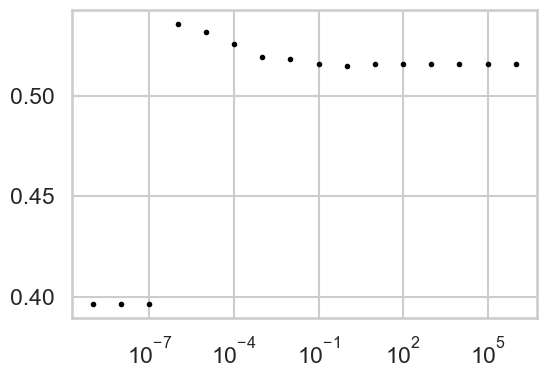

In [90]:

fig, ax = plt.subplots(1, 1, figsize=(6,4))

ax.errorbar(reg_par, cv_mean, yerr=cv_var, fmt="o", color="black", markersize=3)
ax.set_xscale("log")

In [91]:
cv_mean

array([0.39656132, 0.39656132, 0.39656132, 0.53551875, 0.53180682,
       0.52580895, 0.51931562, 0.51838272, 0.51602496, 0.51482919,
       0.51563341, 0.51563341, 0.51563341, 0.51563341, 0.51563341,
       0.51563341])

In [92]:
reg_par[3]

1e-06

In [93]:
lr = LogisticRegression(penalty="l2", C=1e-6, class_weight="balanced")
lr.fit(X_train, y_train)

LogisticRegression(C=1e-06, class_weight='balanced')

In [94]:
lr.score(X_val, y_val)

0.8012562814070352

In [95]:
pred_val = lr.predict(X_val)

In [98]:
f1_score(np.array(y_val), np.array(pred_val), average="macro")

0.5162135269597956

(<Figure size 1000x400 with 4 Axes>,
 array([<Axes: xlabel='0', ylabel='5'>, <Axes: xlabel='0', ylabel='6'>,
        <Axes: xlabel='0', ylabel='7'>, <Axes: xlabel='0', ylabel='8'>],
       dtype=object))

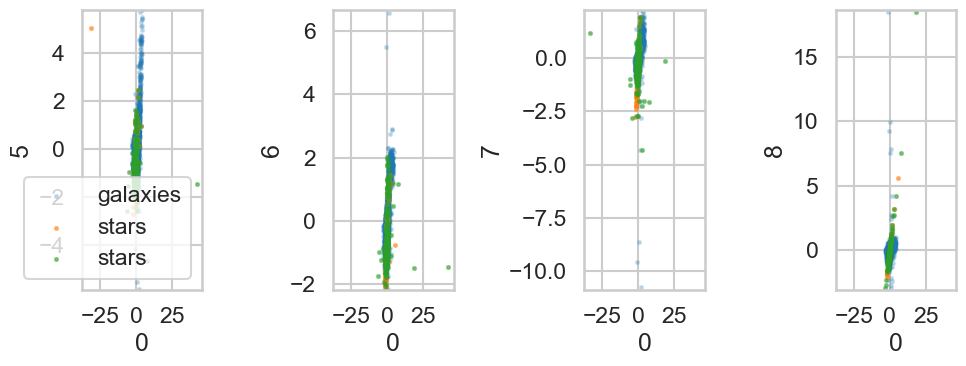

In [97]:
plot_misclassified(X_val, y_val, pred_val)

### Evaluation: ROC Curve

Recall that the logistic regression classifier returns a *probability* that a given sample belongs to class 1 (stars). Internally, to decide on a label, the software applies a threshold on that probability, above which it'll predict the label STAR, and below which it will predict the label GALAXY. By default, that threshold is usually 0.5, but it doesn't *have* to be. To see how this threshold affects the results, we can make a plot of the *true positives* (how often we classified stars correctly) versus the *false positives* (how often we accidentally classified galaxies as stars), for different thresholds. This effectively gives us a measure of how often we might miss out on finding stars if we set the threshold too high, versus having too many galaxies in our sample of stars if we set the threshold too low. The best threshold is the one that maximizes true positives while minimizing false negatives. Let's make this plot for our Logistic Regression classifier:



In [98]:
from sklearn.metrics import roc_curve

In [99]:
scores = np.arange(0, 1, 0.01)

In [100]:
fpr, tpr, thresholds = roc_curve(y_train, lr.decision_function(X_train), pos_label="STAR")

Text(0, 0.5, 'True Positive Rate')

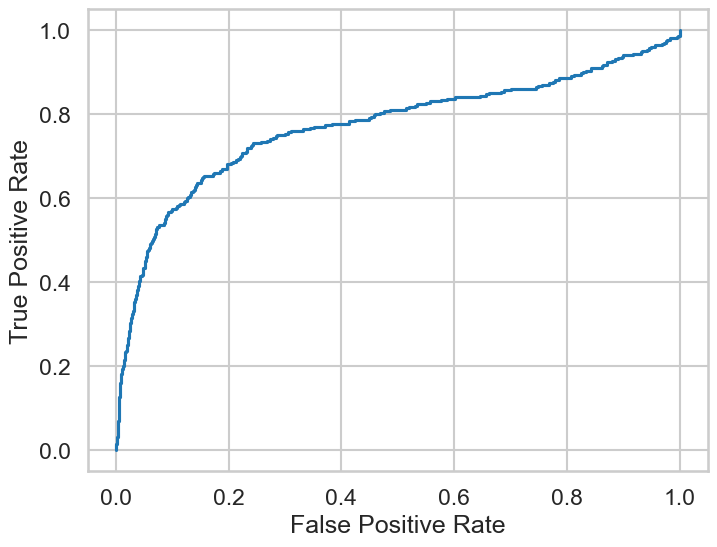

In [101]:
fig, ax = plt.subplots(1, 1, figsize=(8,6))
ax.plot(fpr, tpr)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")

### Evaluation: Confusion Matrices

Another great way to visualize the results of your classifier, especially for multi-class classification problems, is a confusion matrix. Here's an example:

In [102]:
from sklearn.metrics import confusion_matrix

In [103]:
confusion_matrix(y_val, pred_val, labels=["STAR", "GALAXY"])

array([[  67,   33],
       [ 758, 3122]])

You can also directly plot it using a new function:

In [104]:
from sklearn.metrics import ConfusionMatrixDisplay

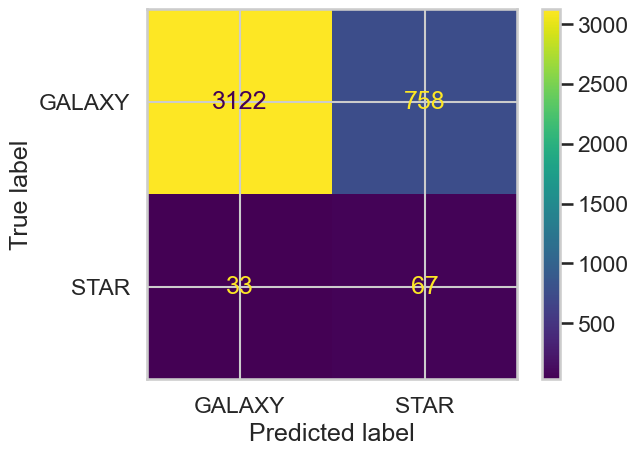

In [105]:
_ = ConfusionMatrixDisplay.from_estimator(lr, X_val, y_val)

On the diagonal are the cases where the classifier got it right: where predicted and true label match, and we've correctly classified a star as a star, and a galaxy as a galaxy. On the off-diagonal are the cases where we've done it wrong: where a galaxy has been classified as a star, and the reverse.

## Interpretation

**Exercise**: So what do we do with the results we've got so far? Are they good results? Discuss with a partner whether our results are meaningful under two scenarios: 
(1) We want to make very sure we've only got stars in our sample, because we're going to send expensive interstellar probes to each to say hi in case there's life on them, so we don't want to unnecessarily send them to a far-away galaxy.
(2) We want to make sure we absolutely have *all* stars in the sample, even if we get some galaxies, too, because we'd like to schedule some (not super expensive) follow-up radio observations to see if we can find any alien-made signals.
Based on the work we've done so far, what might you change in the analysis we've done?

## More Complex Algorithms

One reason why our model isn't working well is because logistic regression is a really simple algorithm. It essentially draws a line (in 2D, a hyperplane in higher-dimensional spaces) in the space in such a way to maximize the distance between the line and samples from the two classes. 

However, as with regular regression, a linear model may not be a great fit to the problem you're trying to solve, if your feature space is more complex. There are *many* algorithms out there that can classify more complex problems, including neural networks. Here, we're going to use a Random Forest for comparison. We're not going to go into detail into how random forests work here, suffice to say that they're reasonably straightforward. 

In [106]:
from sklearn.ensemble import RandomForestClassifier

In [107]:
rf = RandomForestClassifier(n_estimators=100)
cross_val_score(rf, X_train, y_train, cv=5)

array([0.98743719, 0.98869347, 0.98743719, 0.99036851, 0.98994975])

In [108]:
rf.fit(X_train, y_train)

RandomForestClassifier()

In [109]:
rf.score(X_train, y_train)

1.0

In [110]:
rf.score(X_val, y_val)

0.9884422110552764

In [111]:
pred_val = rf.predict(X_val)

Let's use a version of the F1-score, which puts the same weight on both classes:

In [112]:
f1_score(np.array(y_val), np.array(pred_val), average="macro")

0.8617533791436985

That looks better than the logistic regression!

In [113]:
mask = (pred_val != y_val)

In [114]:
pd.Series(y_val[mask]).value_counts()

STAR      38
GALAXY     8
Name: count, dtype: int64

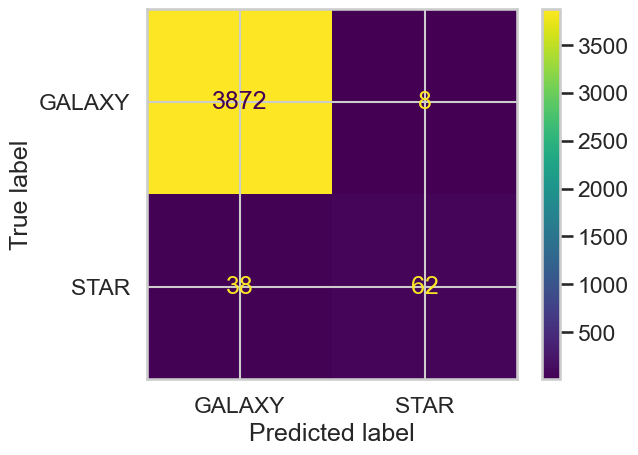

In [115]:
_ = ConfusionMatrixDisplay.from_estimator(rf, X_val, y_val)

Looks like performance on stars is about the same, but the false positive rate has gone *way* down, which is great!

**Exercise**: Can we make this *even* better by cross-validating and choosing less standard parameters?

In [116]:
n_estimators_all = [100, 200, 500, 1000]

# mean and variances of CV scores
cv_mean = []
cv_var = []
for i,n in enumerate(n_estimators_all):
    rf = RandomForestClassifier(n_estimators=n)
    sc = cross_val_score(rf, X_val, y_val, cv=5, scoring="f1_macro")
    sc_mean = np.mean(sc)
    sc_var = np.var(sc)

    cv_mean.append(sc_mean)
    cv_var.append(sc_var)

cv_mean = np.array(cv_mean)
cv_var = np.array(cv_var)

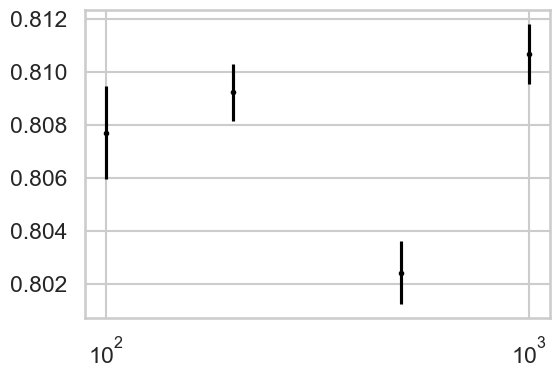

In [117]:
fig, ax = plt.subplots(1, 1, figsize=(6,4))

ax.errorbar(n_estimators_all, cv_mean, yerr=cv_var, fmt="o", color="black", markersize=3)
ax.set_xscale("log")

## Reporting Your Results

Let's say we're happy with our Random Forest classifier. Let's train it one last time, on all of the training + validation data:

In [118]:
X_train_all = np.vstack([X_train, X_val])

In [119]:
y_train_all = np.hstack([y_train, y_val])

In [120]:
rf = RandomForestClassifier(n_estimators=200)
rf.fit(X_train_all, y_train_all)

RandomForestClassifier(n_estimators=200)

Now comes the moment of truth: where we get our test data back and calculate the scores on data the algorithm (and you) has never seen before! Exciting! Let's load our data:

In [121]:
X_test = pd.read_csv("sdss_dataset1_test.csv", index_col=0)
y_test = pd.read_csv("sdss_dataset1_test_labels.csv", index_col=0)

In [122]:
X_test

,dered_u,dered_g,dered_r,dered_i,dered_z,u_g_color,g_r_color,r_i_color,i_z_color
451,20.14081,18.43025,17.70263,17.33621,17.14871,1.710566,0.727619,0.366421,0.187502
10347,19.31625,17.72975,17.01156,16.63057,16.37063,1.586496,0.718197,0.380985,0.259945
3153,21.07108,19.15829,17.67019,17.08202,16.64710,1.912796,1.488094,0.588171,0.434921
7687,19.48932,18.35139,18.00494,17.78185,17.67290,1.137924,0.346455,0.223091,0.108950
13020,20.79003,18.68674,17.40938,16.86964,16.56916,2.103292,1.277365,0.539738,0.300474
...,...,...,...,...,...,...,...,...,...
13936,26.55105,20.45103,18.46178,17.67704,17.27259,6.100019,1.989250,0.784740,0.404448
14691,21.95295,19.91335,18.36432,17.78055,17.40105,2.039597,1.549026,0.583775,0.379499
9223,19.39376,17.59227,16.72777,16.28404,15.96932,1.801489,0.864500,0.443733,0.314713
3718,19.21397,17.21449,16.18817,15.74375,15.36139,1.999485,1.026318,0.444414,0.382367


Don't forget that we need to do *everything* we did to the training data also to the test data! This includes *all* pre-processing steps. What have we done since we split out the training data?

In our case, only the standard scaling. If you'd transformed your features in some way, this is also something you'd now want to do on your test data:

In [123]:
X_test_scaled = scaler.transform(X_test)

If you'd applied other transformations (e.g. PCA), you'd want to make sure to apply them here, too. One useful utility that scikit-learn provides here are [pipelines](https://scikit-learn.org/stable/modules/compose.html) which allow you to string together multiple steps into a single class to train and evaluate. This can also be useful if you'd like to cross-validate multiple steps together. 

Let's get back to our evaluation on the test data. Now we can use the test data to predict classes for the model, and check the results against the true labels:

In [124]:
pred_test = rf.predict(X_test_scaled)

In [125]:
f1_score(y_test, pred_test, average="macro")

0.8954154309599981

Nice! That performance is really good, and similar to what we've seen on the validation data! Hooray! Let's make a confusion matrix:

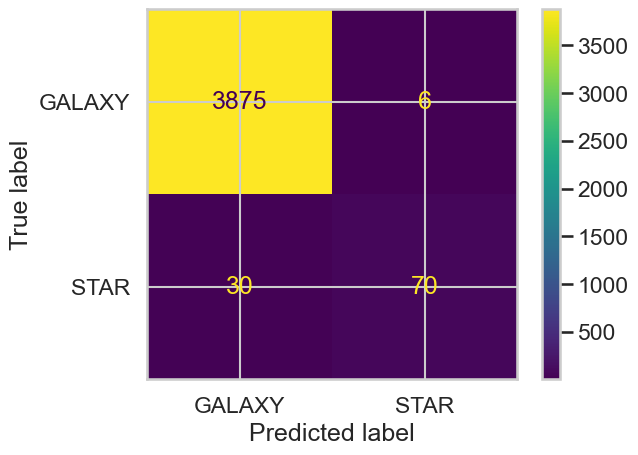

In [126]:
_ = ConfusionMatrixDisplay.from_estimator(rf, X_test_scaled, y_test)

This is part of what you might now report in your paper, along with a more in-depth exploration of where the algorithm may be biased, together with any downstream tasks you're using the classification for. 

## Advanced

There are many things we didn't get to in this tutorial that can be important for building a good machine learning analysis. Here are some ideas for what to explore next:
* **Pipelines**: scikit-learn allows it to string several algorithms together in a *pipeline*, for example a PCA transform of some features with a Random Forest Classifier. This can make it easier to cross-validate choices made during the initial feature engineering stage. Try out stringing together some algorithsm
* **Write your own class**: Scikit-learn comes with easy templates for writing your own transforms or algorithms. This can be especially useful again when feature engineering. Try to write some way of transforming your data into a transform class and include it in your pipeline!